# Project Phase II: Applied Data Engineering and Machine Learning

## Original LCS System on raw Dataset

In [8]:
import pandas as pd

# Load the raw dataset
df = pd.read_csv("../data/student-course-completion-prediction-dataset-original.csv")

df_copy = df.head(500).copy(deep=True)
total_count = len(df_copy)

print(f"Total selected: {total_count}")
display(df_copy.head())

Total selected: 500


,Student_ID,Name,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,...,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,Payment_Amount,App_Usage_Percentage,Reminder_Emails_Clicked,Support_Tickets_Raised,Satisfaction_Rating,Completed
0,STU100000,Vihaan Patel,Male,19,Diploma,Student,Indore,Laptop,Medium,C102,...,01-06-2024,Scholarship,No,No,1740,49,3,4,3.5,Completed
1,STU100001,Arjun Nair,Female,17,Bachelor,Student,Delhi,Laptop,Low,C106,...,27-04-2025,Credit Card,Yes,No,6147,86,0,0,4.5,Not Completed
2,STU100002,Aditya Bhardwaj,Female,34,Master,Student,Chennai,Mobile,Medium,C101,...,20-01-2024,NetBanking,Yes,No,4280,85,1,0,5.0,Completed
3,STU100003,Krishna Singh,Female,29,Diploma,Employed,Surat,Mobile,High,C105,...,13-05-2025,UPI,Yes,No,3812,42,2,3,3.8,Completed
4,STU100004,Krishna Nair,Female,19,Master,Self-Employed,Lucknow,Laptop,Medium,C106,...,19-12-2024,Debit Card,Yes,Yes,5486,91,3,0,4.0,Completed


In [9]:
for col in df_copy.columns:
    print(f"{col}: {df_copy[col].dtype}, unique: {df_copy[col].nunique(dropna=True)}")

Student_ID: str, unique: 500
Name: str, unique: 245
Gender: str, unique: 3
Age: int64, unique: 26
Education_Level: str, unique: 5
Employment_Status: str, unique: 4
City: str, unique: 15
Device_Type: str, unique: 3
Internet_Connection_Quality: str, unique: 3
Course_ID: str, unique: 8
Course_Name: str, unique: 8
Category: str, unique: 5
Course_Level: str, unique: 3
Course_Duration_Days: int64, unique: 8
Instructor_Rating: float64, unique: 7
Login_Frequency: int64, unique: 11
Average_Session_Duration_Min: int64, unique: 56
Video_Completion_Rate: float64, unique: 369
Discussion_Participation: int64, unique: 9
Time_Spent_Hours: float64, unique: 121
Days_Since_Last_Login: int64, unique: 34
Notifications_Checked: int64, unique: 14
Peer_Interaction_Score: float64, unique: 84
Assignments_Submitted: int64, unique: 11
Assignments_Missed: int64, unique: 11
Quiz_Attempts: int64, unique: 11
Quiz_Score_Avg: float64, unique: 300
Project_Grade: float64, unique: 330
Progress_Percentage: float64, unique:

In [10]:
# Start from the raw working dataset
baseline_df = df_copy.copy()

# Remove columns that should not be predictors
baseline_df = baseline_df.drop(
    columns=[
        "Student_ID",  # identifier only
        "Name",  # free-text identifier
    ],
    errors="ignore",
)

# Convert Enrollment_Date only because eLCS needs numeric input
if "Enrollment_Date" in baseline_df.columns:
    baseline_df["Enrollment_Date"] = pd.to_datetime(
        baseline_df["Enrollment_Date"], dayfirst=True
    )

    baseline_df["Enrollment_Year"] = baseline_df["Enrollment_Date"].dt.year
    baseline_df["Enrollment_Month"] = baseline_df["Enrollment_Date"].dt.month
    baseline_df["Enrollment_Day"] = baseline_df["Enrollment_Date"].dt.day

    baseline_df = baseline_df.drop(columns=["Enrollment_Date"])

# Separate target from predictors
y_baseline = baseline_df["Completed"].copy()
X_baseline = baseline_df.drop(columns=["Completed"]).copy()

# Convert categorical predictors to numeric codes
categorical_cols = X_baseline.select_dtypes(
    include=["object", "string", "category"]
).columns

for col in categorical_cols:
    X_baseline[col] = X_baseline[col].astype("category").cat.codes

# Convert target to binary numeric values
y_baseline = y_baseline.map({"Completed": 1, "Not Completed": 0})

# Verify that the minimally processed baseline is ready
print("Baseline feature shape:", X_baseline.shape)
print("Baseline target shape:", y_baseline.shape)

print("\nNon-numeric predictor columns:")
print(X_baseline.select_dtypes(exclude="number").columns.tolist())

print("\nMissing target values:")
print(y_baseline.isna().sum())

print("\nTarget classes:")
print(set(y_baseline))

Baseline feature shape: (500, 39)
Baseline target shape: (500,)

Non-numeric predictor columns:
[]

Missing target values:
0

Target classes:
{0, 1}


In [11]:
from sklearn.model_selection import train_test_split

# Split the minimally processed baseline data
X_train, X_test, y_train, y_test = train_test_split(
    X_baseline, y_baseline, test_size=0.20, random_state=42, stratify=y_baseline
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training features: (400, 39)
Testing features: (100, 39)
Training target: (400,)
Testing target: (100,)

Training class distribution:
Completed
1    202
0    198
Name: count, dtype: int64

Testing class distribution:
Completed
1    50
0    50
Name: count, dtype: int64


In [12]:
from skeLCS import eLCS

print("eLCS import successful")

# Create the original eLCS baseline model
baseline_elcs_model = eLCS(learning_iterations=5000, track_accuracy_while_fit=False)

print("Baseline eLCS model created.")

eLCS import successful
Baseline eLCS model created.


In [13]:
# Train the original eLCS model
baseline_elcs_model = baseline_elcs_model.fit(X_train.values, y_train.values)

print("eLCS training complete")

eLCS training complete


Original eLCS Baseline Performance
----------------------------------
Accuracy:          0.5100
Precision:         0.5051
Recall:            1.0000
F1 Score:          0.6711
Balanced Accuracy: 0.5100
Mean Cost: 4.9000
ROC AUC: 0.5000
PRC AUC: 0.7500

Confusion Matrix:
[[ 1 49]
 [ 0 50]]
Roc/PRC curves


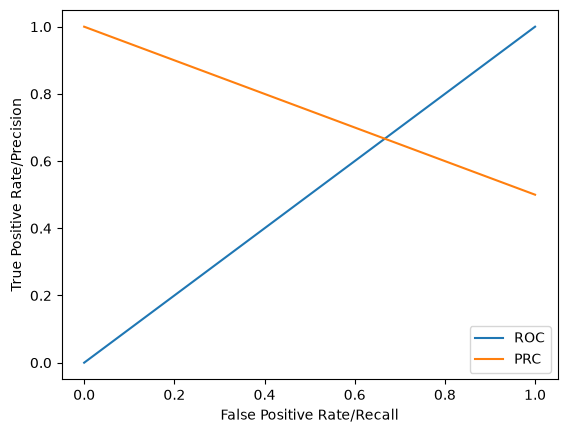

Final Training Accuracy: 0.9722222222222222
Final Instance Coverage: 0.9625
Final Attribute Specificity List: [484, 486, 469, 493, 469, 486, 497, 513, 510, 471, 492, 492, 515, 483, 480, 501, 525, 495, 482, 482, 483, 477, 518, 457, 453, 526, 443, 482, 487, 499, 518, 490, 490, 555, 499, 466, 517, 452, 454]
Final Attribute Accuracy List: [473.2666666666667, 476.2666666666667, 459.2666666666667, 484.0, 458.0, 481.0, 488.0, 503.0, 498.9333333333334, 464.0, 484.0, 483.2666666666667, 511.0, 474.0, 466.2666666666667, 492.2666666666667, 514.0, 489.0, 474.2666666666667, 471.2666666666667, 473.0, 467.0, 508.9333333333334, 444.0, 449.6, 512.2666666666667, 432.6666666666667, 477.0, 479.0, 486.0, 506.2666666666667, 485.0, 483.0, 546.0, 488.6666666666667, 457.6666666666667, 505.9333333333334, 442.0, 448.2666666666667]


In [14]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
)

# Make predictions on the test dataset
y_pred_baseline = baseline_elcs_model.predict(X_test.values)
probabilities = baseline_elcs_model.predict_proba(X_test.values)

# Calculate baseline performance metrics
accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline)
recall = recall_score(y_test, y_pred_baseline)
f1 = f1_score(y_test, y_pred_baseline)
balanced_acc = balanced_accuracy_score(y_test, y_pred_baseline)
false_negative_cost = 10.0
false_positive_cost = 1.0
false_negatives = ((y_test == 0) & (y_pred_baseline == 1)).sum()
false_positives = ((y_test == 1) & (y_pred_baseline == 0)).sum()
mean_cost = (
    false_negative_cost * false_negatives
    + false_positive_cost * false_positives
) / len(y_test)

# Receiver Operating Characteristic curve
fpr, tpr, thresholds_roc = roc_curve(y_test, probabilities[:, 1])
# Precision-Recall curve
precision_curve, recall_curve, thresholds_prc = precision_recall_curve(
    y_test, probabilities[:, 1]
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)

print("Original eLCS Baseline Performance")
print("----------------------------------")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"F1 Score:          {f1:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Mean Cost: {mean_cost:.4f}")
print(f"ROC AUC: {auc(fpr, tpr):.4f}")
print(f"PRC AUC: {auc(recall_curve, precision_curve):.4f}")

print("\nConfusion Matrix:")
print(cm)

print("Roc/PRC curves")
plt.plot(fpr, tpr, label="ROC")
plt.plot(recall_curve, precision_curve, label="PRC")
plt.xlabel("False Positive Rate/Recall")
plt.ylabel("True Positive Rate/Precision")
plt.legend()
plt.show()

print("Final Training Accuracy: " + str(baseline_elcs_model.get_final_accuracy()))
print(
    "Final Instance Coverage: " + str(baseline_elcs_model.get_final_instance_coverage())
)
print(
    "Final Attribute Specificity List: "
    + str(baseline_elcs_model.get_final_attribute_specificity_list())
)
print(
    "Final Attribute Accuracy List: "
    + str(baseline_elcs_model.get_final_attribute_accuracy_list())
)

In [15]:
export_dir = "../data/export/"
baseline_iteration_tracking_file = (
    f"{export_dir}/baseline_elcs_model_iteration_data.csv"
)

baseline_elcs_model.export_iteration_tracking_data(baseline_iteration_tracking_file)
baseline_elcs_model_iteration_data = pd.read_csv(baseline_iteration_tracking_file)

display(baseline_elcs_model_iteration_data)

,Iteration,Accuracy (approx),Average Population Generality,Macropopulation Size,Micropopulation Size,Match Set Size,Correct Set Size,Average Iteration Age of Correct Set Classifiers,# Classifiers Subsumed in Iteration,# Crossover Operations Performed in Iteration,# Mutation Operations Performed in Iteration,# Covering Operations Performed in Iteration,# Deletion Operations Performed in Iteration,Total Global Time,Total Matching Time,Total Deletion Time,Total Subsumption Time,Total Selection Time,Total Evaluation Time
0,0,0,0.000000,1,1,1,1,0.0,0,0,0,1,0,0.076859,0.000008,0.000002,0.000000,0.000000,0.000000
1,1,0,0.000000,2,2,1,1,1.0,0,0,0,1,0,0.076921,0.000012,0.000003,0.000000,0.000000,0.000012
2,2,0,0.000000,3,3,1,1,2.0,0,0,0,1,0,0.076970,0.000015,0.000003,0.000000,0.000000,0.000014
3,3,0,0.000000,4,4,1,1,3.0,0,0,0,1,0,0.077011,0.000018,0.000003,0.000000,0.000000,0.000015
4,4,0,0.000000,5,5,1,1,4.0,0,0,0,1,0,0.077057,0.000022,0.000004,0.000000,0.000000,0.000017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,0,0.511718,939,1000,2,2,4595.0,0,0,2,0,2,10.210778,3.663301,3.589996,2.140688,0.063669,0.023512
4996,4996,0,0.511718,939,1000,1,1,4596.0,0,0,2,0,2,10.212641,3.663777,3.590883,2.141097,0.063674,0.023513
4997,4997,0,0.511718,938,1000,2,2,3797.0,0,0,1,0,2,10.215533,3.665178,3.591860,2.141429,0.063700,0.023520
4998,4998,0,0.511718,937,1000,1,1,4598.0,0,0,1,0,2,10.217611,3.666006,3.592698,2.141730,0.063711,0.023524


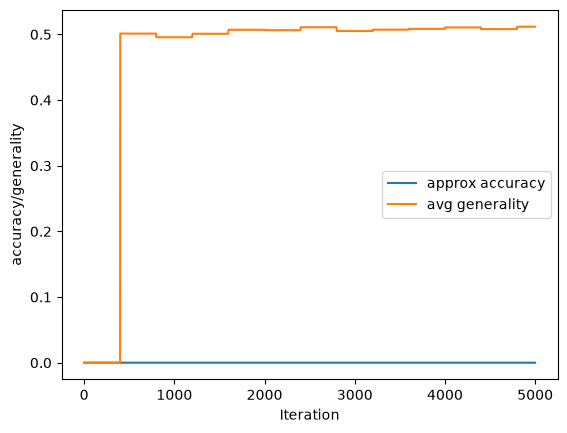

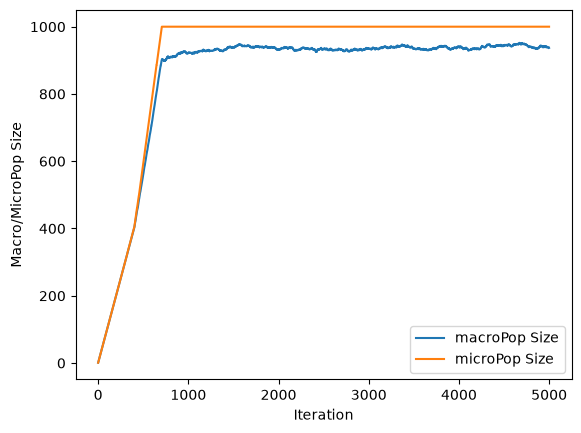

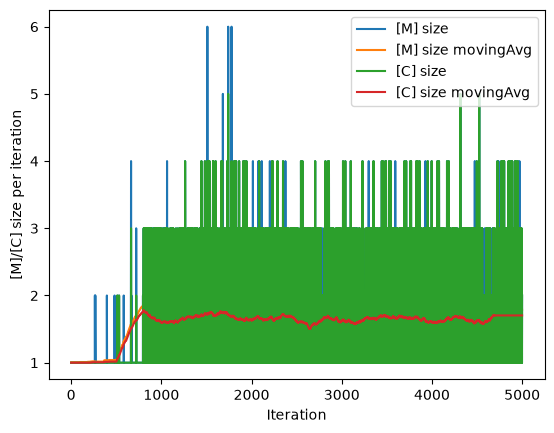

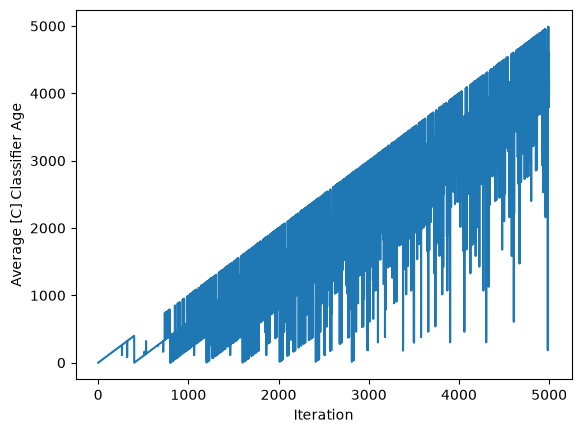

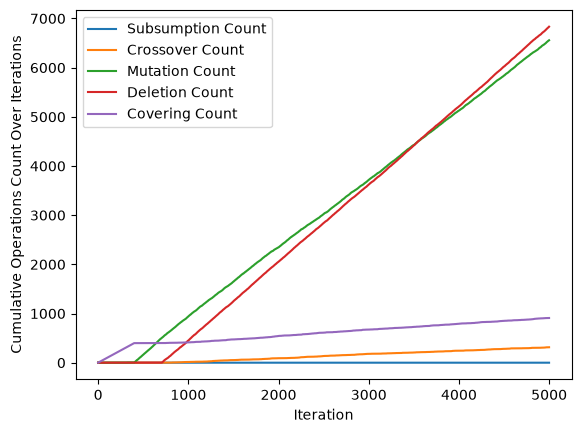

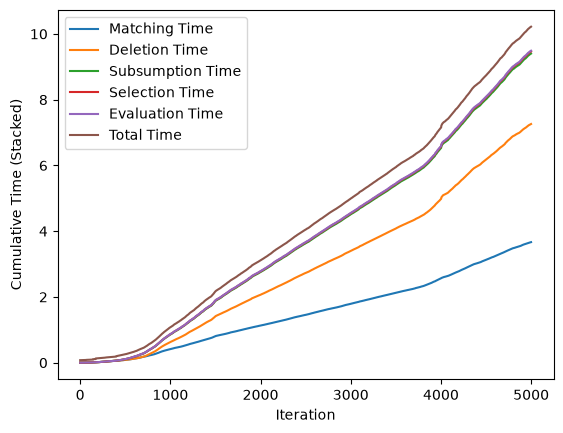

In [16]:
# Display the iteration tracking data for the baseline eLCS model
import numpy as np


def cumulativeFreq(freq):
    a = []
    c = []
    for i in freq:
        a.append(i + sum(c))
        c.append(i)
    return np.array(a)


def movingAvg(a, threshold=300):
    weights = np.repeat(1.0, threshold) / threshold
    conv = np.convolve(a, weights, "valid")
    return np.append(
        conv,
        np.full(threshold - 1, conv[conv.size - 1]),
    )


iterations = baseline_elcs_model_iteration_data["Iteration"].values
accuracy = baseline_elcs_model_iteration_data["Accuracy (approx)"].values
generality = baseline_elcs_model_iteration_data["Average Population Generality"].values
macroPop = baseline_elcs_model_iteration_data["Macropopulation Size"].values
microPop = baseline_elcs_model_iteration_data["Micropopulation Size"].values
mSize = baseline_elcs_model_iteration_data["Match Set Size"].values
cSize = baseline_elcs_model_iteration_data["Correct Set Size"].values
experience = baseline_elcs_model_iteration_data[
    "Average Iteration Age of Correct Set Classifiers"
].values
subsumption = baseline_elcs_model_iteration_data[
    "# Classifiers Subsumed in Iteration"
].values
crossover = baseline_elcs_model_iteration_data[
    "# Crossover Operations Performed in Iteration"
].values
mutation = baseline_elcs_model_iteration_data[
    "# Mutation Operations Performed in Iteration"
].values
covering = baseline_elcs_model_iteration_data[
    "# Covering Operations Performed in Iteration"
].values
deletion = baseline_elcs_model_iteration_data[
    "# Deletion Operations Performed in Iteration"
].values

gTime = baseline_elcs_model_iteration_data["Total Global Time"].values
mTime = baseline_elcs_model_iteration_data["Total Matching Time"].values
delTime = baseline_elcs_model_iteration_data["Total Deletion Time"].values
subTime = baseline_elcs_model_iteration_data["Total Subsumption Time"].values
selTime = baseline_elcs_model_iteration_data["Total Selection Time"].values
evalTime = baseline_elcs_model_iteration_data["Total Evaluation Time"].values

plt.plot(iterations, accuracy, label="approx accuracy")
plt.plot(iterations, generality, label="avg generality")
plt.xlabel("Iteration")
plt.ylabel("accuracy/generality")
plt.legend()
plt.show()

plt.plot(iterations, macroPop, label="macroPop Size")
plt.plot(iterations, microPop, label="microPop Size")
plt.xlabel("Iteration")
plt.ylabel("Macro/MicroPop Size")
plt.legend()
plt.show()

plt.plot(iterations, mSize, label="[M] size")
plt.plot(iterations, movingAvg(mSize), label="[M] size movingAvg")
plt.plot(iterations, cSize, label="[C] size")
plt.plot(iterations, movingAvg(cSize), label="[C] size movingAvg")
plt.xlabel("Iteration")
plt.ylabel("[M]/[C] size per iteration")
plt.legend()
plt.show()

plt.plot(iterations, experience)
plt.ylabel("Average [C] Classifier Age")
plt.xlabel("Iteration")
plt.show()

plt.plot(iterations, cumulativeFreq(subsumption), label="Subsumption Count")
plt.plot(iterations, cumulativeFreq(crossover), label="Crossover Count")
plt.plot(iterations, cumulativeFreq(mutation), label="Mutation Count")
plt.plot(iterations, cumulativeFreq(deletion), label="Deletion Count")
plt.plot(iterations, cumulativeFreq(covering), label="Covering Count")
plt.xlabel("Iteration")
plt.ylabel("Cumulative Operations Count Over Iterations")
plt.legend()
plt.show()

plt.plot(iterations, mTime, label="Matching Time")
plt.plot(iterations, delTime + mTime, label="Deletion Time")
plt.plot(iterations, subTime + delTime + mTime, label="Subsumption Time")
plt.plot(iterations, selTime + subTime + delTime + mTime, label="Selection Time")
plt.plot(
    iterations, evalTime + selTime + subTime + delTime + mTime, label="Evaluation Time"
)
plt.plot(iterations, gTime, label="Total Time")
plt.xlabel("Iteration")
plt.ylabel("Cumulative Time (Stacked)")
plt.legend()
plt.show()

In [17]:
# Export the final rule population to a CSV file

baseline_elcs_model_final_rule_population_file = (
    f"{export_dir}/baseline_elcs_model_final_rule_population.csv"
)

baseline_elcs_model.export_final_rule_population(
    X_baseline.columns.to_numpy(),
    "Completed",
    filename=baseline_elcs_model_final_rule_population_file,
    DCAL=False,
)

baseline_elcs_model_final_rule_populationData = pd.read_csv(
    baseline_elcs_model_final_rule_population_file
)
display(baseline_elcs_model_final_rule_populationData)

,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,Course_Name,Category,...,Fitness,Accuracy,Numerosity,Avg Match Set Size,TimeStamp GA,Iteration Initialized,Specificity,Deletion Probability,Correct Count,Match Count
0,#,"19.42,36.58",#,#,#,1.0,#,5.0,#,#,...,1.0,1.0,1,1.621349,4985,185,0.538462,0.000851,13,13
1,0.0,"19.64,38.36",#,2.0,"5.38,14.620000000000001",0.0,#,3.0,1.0,#,...,0.1,1.0,1,1.000000,780,780,0.538462,0.000525,0,0
2,#,"12.41,23.59",#,0.0,"-2.4299999999999997,4.43",#,1.0,#,#,#,...,1.0,1.0,1,1.929600,4927,1327,0.461538,0.001012,9,9
3,#,#,0.0,0.0,"5.73,14.27",#,1.0,#,4.0,#,...,1.0,1.0,2,2.190400,4672,1472,0.487179,0.002298,9,9
4,1.0,"23.939999999999998,40.06",0.0,2.0,#,0.0,#,#,#,#,...,1.0,1.0,1,2.128000,4790,1590,0.512821,0.001116,8,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932,1.0,#,#,#,"-1.4299999999999997,5.43",#,2.0,#,7.0,1.0,...,0.1,1.0,1,1.000000,4996,4996,0.512821,0.000525,0,0
933,0.0,#,0.0,#,#,#,#,#,#,#,...,0.1,1.0,1,2.250000,4997,4997,0.512821,0.001180,0,0
934,#,"14.8,25.2",0.0,#,#,#,2.0,#,#,#,...,0.1,1.0,1,1.000000,4998,4998,0.384615,0.000525,0,0
935,0.0,#,#,0.0,"5.22,12.780000000000001",#,#,3.0,1.0,#,...,0.1,1.0,1,1.500000,4999,4999,0.410256,0.000787,0,0


Minimal processing: 
-Student_ID removed because it is only an identifier and not a meaningful predictor.
-Name removed because it is free-text/identifier information.
-Completed_Status removed because it was derived from the target and would cause target leakage.
-Enrollment_Date converted into numeric year/month/day values because eLCS requires numeric inputs.
-Categorical predictors such as Gender, City, Course_Level, etc. converted into numeric category codes so eLCS could process them.
-Completed converted from Completed / Not Completed into 1 / 0 because the model needs numeric class labels.
-No feature engineering, scaling, tuning, balancing, or optimisation was applied at this stage, so this remains the raw/minimally processed baseline.